# 02 — GRPO Reinforcement Learning

This notebook applies **Group Relative Policy Optimization (GRPO)** in two separate runs:

**Run A — GRPO from SFT:** Merges the SFT LoRA adapter and continues training with GRPO.

**Run B — GRPO from Instruct:** Starts directly from `Qwen2.5-Math-7B-Instruct` with no SFT step.

**Dataset:** GSM8K (grade school math — clean learning signal for GRPO)

**Requirements:** Google Colab with A100 GPU (High-RAM recommended). Run A and B in separate sessions to avoid VRAM conflicts.

## 1. Setup

In [1]:
# Clone the repo
!git clone https://github.com/Roogard/math-rl-tuning.git
%cd math-rl-tuning

# Install dependencies
!pip install "protobuf<5" --quiet
!pip install unsloth --quiet
!pip install -e . --quiet
!pip install bitsandbytes latex2sympy2 --quiet

Cloning into 'math-rl-tuning'...
remote: Enumerating objects: 503, done.
remote: Counting objects: 100% (151/151), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 503 (delta 82), reused 103 (delta 44), pack-reused 352 (from 1)
Receiving objects: 100% (503/503), 4.31 MiB | 14.38 MiB/s, done.
Resolving deltas: 100% (306/306), done.
/content/math-rl-tuning
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 29.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have p

In [2]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"GPU:     {torch.cuda.get_device_name(0)}")
print(f"VRAM:    {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

import importlib.util
print(f"Unsloth: {'installed' if importlib.util.find_spec('unsloth') else 'NOT found'}")
print("All imports OK")

PyTorch: 2.10.0+cu128
GPU:     NVIDIA A100-SXM4-80GB
VRAM:    85.1 GB
Unsloth: installed
All imports OK


## 2. Configuration

In [3]:
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


In [ ]:
from math_rl_tuning.config import load_config
from math_rl_tuning.utils import setup_hf_token, setup_wandb, mount_google_drive

cfg = load_config()

# --- Authentication ---
setup_hf_token()
setup_wandb(cfg.grpo_training.report_to and "math-rl-grpo")

# Mount Google Drive (to load SFT adapter and save RL models)
mount_google_drive()

# --- Paths ---
SFT_ADAPTER_PATH = "/content/drive/MyDrive/math-rl-tuning/sft"
GRPO_FROM_SFT_OUTPUT = cfg.paths.grpo_from_sft_output_dir          # ./outputs/grpo_from_sft
GRPO_FROM_INSTRUCT_OUTPUT = cfg.paths.grpo_from_instruct_output_dir  # ./outputs/grpo_from_instruct

# --- Checkpoint Resume ---
# To resume from a crashed run, paste the checkpoint folder path here.
# Leave as None to start fresh.
GRPO_CHECKPOINT = None  # e.g. "/content/drive/MyDrive/math-rl-tuning/grpo_from_sft/checkpoint-50"

## 3A. GRPO from SFT

Merges the SFT adapter into the base model, then trains a fresh LoRA with GRPO.
Saves the GRPO adapter to Drive at `math-rl-tuning/grpo_from_sft`.

In [ ]:
# Delete old merged model cache if you changed config
!rm -rf outputs/sft_merged

from math_rl_tuning.grpo_trainer import run_grpo_training

cfg.paths.grpo_output_dir = GRPO_FROM_SFT_OUTPUT  # save to grpo_from_sft

trainer, model, tokenizer, reward_callback = run_grpo_training(
    cfg,
    sft_adapter_path=SFT_ADAPTER_PATH,
    save_to_drive=True,
    checkpoint_path=GRPO_CHECKPOINT,
    skip_sft_merge=False,  # merges SFT adapter first (default)
)

## 4. Quick Sanity Check

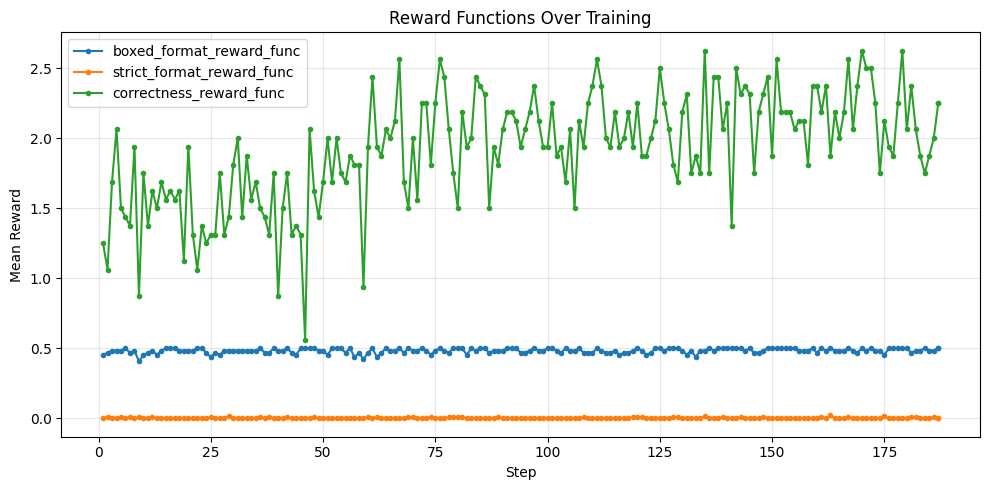

In [6]:
# Plot reward curves — shows how each reward function evolved over training
reward_callback.plot()

In [ ]:
# Plot reward curves for the instruct GRPO run
reward_callback_instruct.plot()

In [ ]:
from math_rl_tuning.config import load_config
from math_rl_tuning.utils import setup_hf_token, setup_wandb, mount_google_drive
from math_rl_tuning.grpo_trainer import run_grpo_training

cfg = load_config()
setup_hf_token()
setup_wandb("math-rl-grpo")
mount_google_drive()

GRPO_FROM_INSTRUCT_OUTPUT = cfg.paths.grpo_from_instruct_output_dir
cfg.paths.grpo_output_dir = GRPO_FROM_INSTRUCT_OUTPUT  # save to grpo_from_instruct

trainer_instruct, model_instruct, tokenizer_instruct, reward_callback_instruct = run_grpo_training(
    cfg,
    save_to_drive=True,
    checkpoint_path=None,
    skip_sft_merge=True,  # loads cfg.model.instruct_name directly (Qwen2.5-Math-7B-Instruct)
)

## 3B. GRPO from Instruct

Loads `Qwen2.5-Math-7B-Instruct` directly with a fresh LoRA and trains with GRPO — no SFT merge step needed.
Saves the GRPO adapter to Drive at `math-rl-tuning/grpo_from_instruct`.

**Run this in a fresh Colab session** (restart runtime after Run A to free VRAM).

In [7]:
from math_rl_tuning.inference import generate

questions = [
    "What is 15% of 240?",
    "Solve for x: 3x + 7 = 22",
    "A rectangle has length 12 cm and width 5 cm. What is its area?",
]

for q in questions:
    print(f"Q: {q}")
    response = generate(q, model, tokenizer)
    print(f"A: {response[:300]}")
    print("-" * 40)

Q: What is 15% of 240?
A: To find 15% of 240, we follow these steps:

Step 1: Convert the percentage to a decimal. 
\[15\% = \frac{15}{100} = 0.15\]

Step 2: Multiply the decimal by the given number.
\[0.15 \times 240 = 36\]

Therefore, 15% of 240 is $\boxed{36}$.
----------------------------------------
Q: Solve for x: 3x + 7 = 22
A: To solve the equation $3x + 7 = 22$, we follow these steps:

1. Subtract 7 from both sides of the equation to isolate the term with the variable:
\[3x + 7 - 7 = 22 - 7\]
This simplifies to:
\[3x = 15\]

2. Divide both sides by 3 to solve for $x$:
\[\frac{3x}{3} = \frac{15}{3}\]
This simplifies to:
\
----------------------------------------
Q: A rectangle has length 12 cm and width 5 cm. What is its area?
A: To find the area of a rectangle, we use the formula:

\[ \text{Area} = \text{Length} \times \text{Width} \]

Given that the length of the rectangle is 12 cm and the width is 5 cm, we substitute these values into the formula:

\[ \text{Area} = 11 \, \te

## 5. Cleanup

In [8]:
from math_rl_tuning.utils import clean_memory

del model, trainer
clean_memory()

Memory cleared.
